# Implementing a VAE for Anomaly Detection

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a **VAE** (encoder → mean/log_var → sample latent → decoder) and train it on MNIST
- Use **reconstruction error** as an **anomaly score** (high error = likely anomaly)
- See why we use a VAE (instead of a plain autoencoder) for a probabilistic latent and anomaly detection

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 01 "Probability Distributions for ML" — a VAE's latent code is a distribution, and the reparameterization trick is how you sample from it and still differentiate.

**Used later in:** Course 10 (AIAT 124) — Unit 1, lesson 04 "Implementing a VAE (Variational Autoencoder) for Image Generation".

---

## 🌍 Real life

**📌 Real case — the benchmark built around "train on normal only".** MVTec AD (Bergmann et al., CVPR 2019) is an industrial inspection dataset of **over 5,000 high-resolution images across 15 object and texture categories**, and its design is the point: for every category, the **training set contains only defect-free images**, while the test set contains defects. It was built that way because that is the situation on a real production line — you have thousands of good parts and almost no examples of the specific fault that will occur next week. The detector you build below follows exactly that protocol: train on 0s alone, then score 0s against 8s the model has never seen.

**⚡ Why this matters — what goes wrong without it.** Fraud, machine failure and manufacturing defects all break supervised learning the same way: you have almost no labelled examples of the thing you want to catch, and the next occurrence will not look like the last one. A classifier needs labelled anomalies and cannot be built. A VAE needs none — it learns only what *normal* looks like, and anything it reconstructs badly is suspicious. Ours never saw an 8 in training and still separates them: mean reconstruction error **0.0202** over 100 normal 0s against **0.0603** over 100 anomalous 8s — a 3.0x gap, and the figure below shows the two distributions barely touching.

**Where is this used?** VAEs are used for **anomaly detection** (fraud, faulty sensors), **generative models**, and **compression** with uncertainty.

**In this notebook we use** a **VAE** to learn a **probabilistic latent** (mean + variance) and **reconstruct** images. We use **reconstruction error** as an anomaly score. We use **VAE** (instead of a plain autoencoder) **because** the latent is **regularized** (KL divergence) so it generalizes; anomalies often have **high reconstruction error**.

**📌 Covers slide(s):** **22** — Variational Autoencoders (VAE). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **VAE:** Encoder outputs **mean** and **log-variance** of the latent; we **sample** z ~ N(mean, var) and decode. Loss = reconstruction (e.g. BCE) + **KL(prior || posterior)** to regularize the latent.
- **Anomaly detection:** Train VAE on **normal** data; at test time, **high reconstruction error** (or high KL) suggests an **anomaly**.
- **We use VAE** instead of a plain autoencoder when we want a **probabilistic** latent and better generalization; the KL term prevents overfitting to the training set.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. MNIST (small subset). We build a simple VAE (dense layers).

**Dataset:** Real — MNIST (small subset).

**Outputs:** Training loss (reconstruction + KL), one figure: **original vs reconstructed** (with axis labels), and a short note on using reconstruction error for anomaly detection.

## Step 1: Imports and load MNIST

In [1]:
# WHAT: imports and MNIST prep (flattened, scaled, small subsets).
# WHY: training on 5,000 images keeps every later VAE cell down to seconds on CPU.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    # Labels are discarded (underscore) - a VAE learns from the images alone.
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)[:5000]
    x_test = x_test.reshape(-1, 784)[:1000]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (5000, 784) Test: (1000, 784)


## Step 2: Build VAE (we use sampling layer so latent is probabilistic; we use VAE instead of AE for regularized latent)

In [2]:
# WHAT: build the VAE - the encoder outputs a DISTRIBUTION (mean, log-variance), a sampler draws z, the decoder reconstructs.
# WHY: unlike a plain autoencoder, the VAE's latent space is smooth and probabilistic - you can sample new digits from it.
if HAS_TF:
    # Fix every random seed so the numbers quoted in this lesson match your run.
    keras.utils.set_random_seed(42)
    latent_dim = 16
    # The 'reparameterization trick': z = mean + sigma * noise keeps the whole path differentiable.
    class Sampling(keras.layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            batch = tf.shape(z_mean)[0]
            eps = tf.random.normal(shape=(batch, latent_dim))
            return z_mean + tf.exp(0.5 * z_log_var) * eps

    # Encoder: one hidden layer, then two heads - z_mean and z_log_var.
    encoder_inp = keras.Input(shape=(784,))
    x = keras.layers.Dense(128, activation="relu")(encoder_inp)
    z_mean = keras.layers.Dense(latent_dim)(x)
    z_log_var = keras.layers.Dense(latent_dim)(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inp, [z_mean, z_log_var, z])

    # Decoder: map a 16-number latent vector back to 784 pixels.
    decoder_inp = keras.Input(shape=(latent_dim,))
    d = keras.layers.Dense(128, activation="relu")(decoder_inp)
    d = keras.layers.Dense(784, activation="sigmoid")(d)
    decoder = keras.Model(decoder_inp, d)

    # Full VAE: encode, sample, decode; the KL term is a second output so the loss can use it.
    vae_inp = keras.Input(shape=(784,))
    z_mean, z_log_var, z = encoder(vae_inp)
    vae_out = decoder(z)
    # KL term per sample (keras.ops keeps KerasTensor in graph). Output [recon, kl] so total loss = recon + kl (add_loss not supported in this Keras).
    kl = -0.5 * keras.ops.sum(1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var), axis=-1)
    vae = keras.Model(vae_inp, [vae_out, kl])

    # Loss = reconstruction error + KL term (keeps the latent distribution close to a standard normal).
    def recon_loss(y_true, y_pred):
        return keras.ops.mean(keras.ops.sum(keras.losses.binary_crossentropy(y_true, y_pred), axis=-1))

    def kl_loss(_, kl_val):
        return kl_val

    vae.compile(optimizer="adam", loss=[recon_loss, kl_loss], loss_weights=[1.0, 1.0])
    vae.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 16),      │    104,608 │ input_layer_2[0]… │
│ (Functional)        │ (None, 16),       │            │                   │
│                     │ (None, 16)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16)        │          0 │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ square (Square)     │ (None, 16)        │          0 │ functional[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 16)        │          0 │ add[0][0],        │
│                     │                   │            │ square[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exp (Exp)           │ (None, 16)        │          0 │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 16)        │          0 │ subtract[0][0],   │
│ (Subtract)          │                   │            │ exp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (Sum)           │ (None)            │          0 │ subtract_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 784)       │    103,312 │ functional[0][2]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None)            │          0 │ sum[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 207,920 (812.19 KB)

 Trainable params: 207,920 (812.19 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (25 epochs, ~3 s on CPU), reconstruct — then generate digits the VAE was never shown

epoch | validation loss (reconstruction BCE + KL)
    1 | 42.91
    5 | 33.62
   10 | 30.64
   25 | 28.73


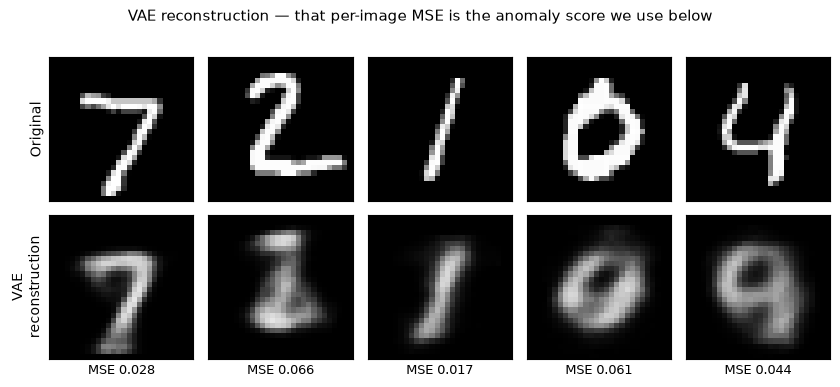

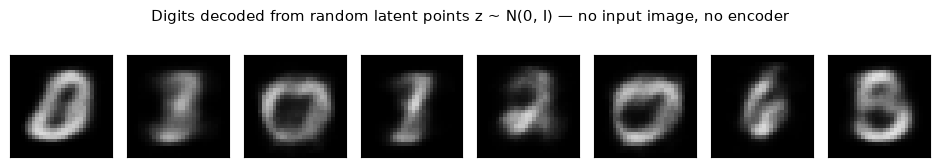

For anomaly detection: compute reconstruction error per sample; high error = likely anomaly.


In [3]:
# WHAT: train the VAE, reconstruct five test digits, then DECODE PURE NOISE.
# WHY: reconstruction error becomes the anomaly score later; the noise row is the thing a plain
#      autoencoder cannot do, and it is what the KL term was paid for.
if HAS_TF:
    # Targets: [reconstruction target, dummy for KL]; model has two outputs [recon, kl].
    y_train = [x_train, np.zeros((len(x_train),))]
    y_test_val = [x_test, np.zeros((len(x_test),))]
    history = vae.fit(x_train, y_train, validation_data=(x_test, y_test_val),
                      epochs=25, batch_size=128, verbose=0)
    print("epoch | validation loss (reconstruction BCE + KL)")
    for e in (1, 5, 10, 25):
        print(f"{e:5d} | {history.history['val_loss'][e - 1]:.2f}")

    recons = vae.predict(x_test[:5], verbose=0)[0]  # first output is reconstruction
    per_img_mse = ((recons - x_test[:5]) ** 2).mean(axis=1)

    # Figure 1 - five test digits above their reconstructions, each with its own error.
    fig, axs = plt.subplots(2, 5, figsize=(8.5, 3.9))
    for i in range(5):
        axs[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axs[1, i].imshow(recons[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axs[1, i].set_xlabel(f"MSE {per_img_mse[i]:.3f}", fontsize=9)
        for r in range(2):
            axs[r, i].set_xticks([]); axs[r, i].set_yticks([])
    axs[0, 0].set_ylabel("Original", fontsize=10)
    axs[1, 0].set_ylabel("VAE\nreconstruction", fontsize=10)
    fig.suptitle("VAE reconstruction — that per-image MSE is the anomaly score we use below", fontsize=11)
    fig.tight_layout(); plt.show()

    # Figure 2 - decode latent points drawn from the PRIOR N(0, I). No input image is involved:
    # randomness IS the lesson here, because a regularized latent is what makes this work at all.
    z_samples = np.random.default_rng(0).normal(size=(8, latent_dim)).astype("float32")
    generated = decoder.predict(z_samples, verbose=0)
    fig, axs = plt.subplots(1, 8, figsize=(9.5, 1.7))
    for i in range(8):
        axs[i].imshow(generated[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axs[i].set_xticks([]); axs[i].set_yticks([])
    fig.suptitle("Digits decoded from random latent points z ~ N(0, I) — no input image, no encoder", fontsize=11)
    fig.tight_layout(); plt.show()
    print("For anomaly detection: compute reconstruction error per sample; high error = likely anomaly.")


**Read the two figures.**

*Top figure.* All five reconstructions are digit-shaped and clearly blurrier than the originals. The 7
and the 1 come back as themselves; the 0 and the 4 come back as rounded shapes that have drifted toward
a 9, and the 2 loses its lower stroke. The per-image MSE printed underneath agrees with your eye — the
barely-changed 1 scores **0.017**, the mangled 2 and 0 score **0.066** and **0.061**. Compare with
lesson `01`, where a plain autoencoder with a 32-number code returned crisper digits: **the extra blur
is the price of the KL term**, which pulls every code toward one shared standard normal instead of
letting each digit keep a private corner of the latent space. That same per-image MSE becomes the
anomaly score in the next section.

*Bottom figure.* This is what the price bought. Those eight images were decoded from latent vectors
drawn straight from N(0, I) — no input image, no encoder, nothing but noise — and they come out as
blurry but digit-like shapes (a 0, a 1, a 6, an 8) rather than static. That is only possible because the
KL term made the region around the origin *mean something*. A plain autoencoder gives you no reason to
expect anything sensible from an arbitrary point in its latent space.

## 🌍 Real-World Worked Example — Anomaly Detection with VAE

**Industry context:**
- **Manufacturing:** MVTec AD (Bergmann et al., CVPR 2019) is an industrial-inspection benchmark of over 5,000 high-resolution images across 15 object and texture categories, built so that each category's **training set contains only defect-free images** — exactly the protocol you follow below.
- **Why that protocol:** on a real line you have thousands of good parts and almost no examples of next week's fault, so "learn normal, then flag surprise" is the only option on the table.
- **Finance and healthcare** use the same shape of model. Treat any vendor claim you meet as unverified until it names its dataset *and* its false-alarm rate — an anomaly detector with no stated false-alarm rate is not a result.

We train a VAE on **normal MNIST digits** then use **reconstruction error** to flag anomalies (digits the VAE has never seen).

Epoch 0 — loss: 314.82


Epoch 5 — loss: 145.82


Epoch 10 — loss: 123.09



Reconstruction error over 100 normal 0s and 100 unseen 8s
  Normal  (0): mean 0.0202   Anomaly (8): mean 0.0603   ratio 3.0x
Higher error = anomaly flagged (the principle behind reconstruction-based fraud and defect detectors)


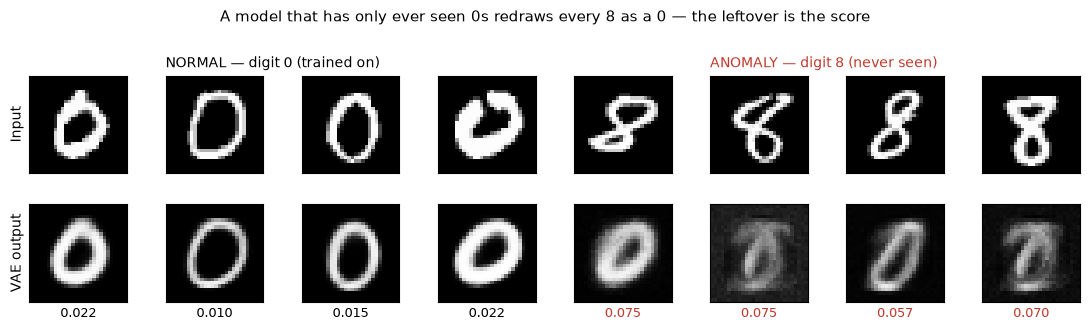

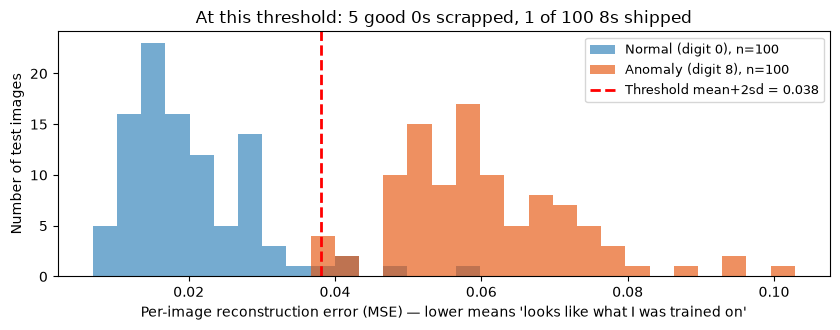


Threshold 0.0381  ->  false alarms 5/100, missed anomalies 1/100


In [4]:
# WHAT: a full PyTorch VAE anomaly detector - train ONLY on digit 0, then score 0s vs 8s by reconstruction error.
# WHY: a model that has only ever seen 'normal' data reconstructs anomalies badly - that error gap IS the detector.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

torch.manual_seed(42)
transform = T.Compose([T.ToTensor()])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
# Train only on digit "0" (normal class). Index the label tensor directly - decoding all
# 60,000 images just to read their labels would cost more than the training run itself.
idx_0 = (dataset.targets == 0).nonzero().flatten()[:2000].tolist()
normal_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(dataset, idx_0), batch_size=64, shuffle=True)

# ── VAE ──────────────────────────────────────────────────────────────────
# Encoder produces mu and log-variance; the decoder rebuilds the image from a 16-dim latent sample.
class VAE(nn.Module):
    def __init__(self, z=16):
        super().__init__()
        self.enc_fc = nn.Sequential(nn.Flatten(), nn.Linear(784,256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        self.dec_fc = nn.Sequential(nn.Linear(z,256), nn.ReLU(), nn.Linear(256,784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc_fc(x)
        return self.mu(h), self.logvar(h)
    # Reparameterization trick: differentiable sampling via mu + sigma * standard-normal noise.
    def reparameterise(self, mu, lv):
        return mu + (0.5*lv).exp() * torch.randn_like(mu)
    def decode(self, z): return self.dec_fc(z).view(-1,1,28,28)
    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparameterise(mu, lv)
        return self.decode(z), mu, lv

model = VAE(); opt = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(15):
    total=0
    for x,_ in normal_loader:
        recon, mu, lv = model(x)
        # Training loss = reconstruction error + KL regularizer, summed over the batch.
        recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss    = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum()
        loss = recon_loss + 0.5*kl_loss
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if epoch%5==0: print(f"Epoch {epoch} — loss: {total/len(idx_0):.2f}")

# ── Anomaly detection: digit 0 (normal) vs digit 8 (anomaly) ──────────────
# 100 of each, so the histogram below is a distribution and not a handful of bars.
model.eval()
test_set = torchvision.datasets.MNIST('/tmp/mnist', train=False, transform=transform)
idx_test_0 = (test_set.targets == 0).nonzero().flatten()[:100]
idx_test_8 = (test_set.targets == 8).nonzero().flatten()[:100]
samples_0 = torch.stack([test_set[i][0] for i in idx_test_0])
samples_8 = torch.stack([test_set[i][0] for i in idx_test_8])

# Score a batch of images by per-image mean squared reconstruction error, and keep the
# reconstructions themselves - the picture of WHY the score is high is worth more than the score.
def recon_error(imgs):
    with torch.no_grad():
        recon,_,_ = model(imgs)
        err = nn.functional.mse_loss(recon, imgs, reduction='none').view(len(imgs),-1).mean(1)
    return err.numpy(), recon

err_0, rec_0 = recon_error(samples_0)
err_8, rec_8 = recon_error(samples_8)
print(f"\nReconstruction error over {len(err_0)} normal 0s and {len(err_8)} unseen 8s")
print(f"  Normal  (0): mean {err_0.mean():.4f}   Anomaly (8): mean {err_8.mean():.4f}"
      f"   ratio {err_8.mean()/err_0.mean():.1f}x")
print("Higher error = anomaly flagged (the principle behind reconstruction-based fraud and defect detectors)")

# ── Figure 1: WHY the error is high - the model can only draw what it was trained on ──
fig, axs = plt.subplots(2, 8, figsize=(11, 3.4))
for i in range(4):
    axs[0, i].imshow(samples_0[i, 0], cmap='gray', vmin=0, vmax=1)
    axs[1, i].imshow(rec_0[i, 0],     cmap='gray', vmin=0, vmax=1)
    axs[1, i].set_xlabel(f"{err_0[i]:.3f}", fontsize=9)
    axs[0, i+4].imshow(samples_8[i, 0], cmap='gray', vmin=0, vmax=1)
    axs[1, i+4].imshow(rec_8[i, 0],     cmap='gray', vmin=0, vmax=1)
    axs[1, i+4].set_xlabel(f"{err_8[i]:.3f}", fontsize=9, color='#c0392b')
for ax in axs.flat:
    ax.set_xticks([]); ax.set_yticks([])
axs[0, 0].set_ylabel("Input", fontsize=10)
axs[1, 0].set_ylabel("VAE output", fontsize=10)
axs[0, 1].set_title("NORMAL — digit 0 (trained on)", fontsize=10, loc='left')
axs[0, 5].set_title("ANOMALY — digit 8 (never seen)", fontsize=10, loc='left', color='#c0392b')
fig.suptitle("A model that has only ever seen 0s redraws every 8 as a 0 — the leftover is the score",
             fontsize=11)
fig.tight_layout(); plt.show()

# ── Figure 2: the two score distributions, and what one threshold would actually cost ──
thr = err_0.mean() + 2*err_0.std()
false_alarms = int((err_0 > thr).sum())     # good 0s we would scrap
missed = int((err_8 <= thr).sum())          # 8s that would ship
bins = np.linspace(min(err_0.min(), err_8.min()), max(err_0.max(), err_8.max()), 30)
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.hist(err_0, bins=bins, alpha=0.65, color='#2c7fb8', label=f"Normal (digit 0), n={len(err_0)}")
ax.hist(err_8, bins=bins, alpha=0.65, color='#e6550d', label=f"Anomaly (digit 8), n={len(err_8)}")
ax.axvline(thr, color='red', linestyle='--', lw=2,
           label=f"Threshold mean+2sd = {thr:.3f}")
ax.set_xlabel("Per-image reconstruction error (MSE) — lower means 'looks like what I was trained on'")
ax.set_ylabel("Number of test images")
ax.set_title(f"At this threshold: {false_alarms} good 0s scrapped, {missed} of {len(err_8)} 8s shipped")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()
print(f"\nThreshold {thr:.4f}  ->  false alarms {false_alarms}/{len(err_0)}, "
      f"missed anomalies {missed}/{len(err_8)}")


**Read the two figures — the first one explains the second.**

*Mechanism (top figure).* Left four columns: real 0s in, near-perfect 0s out. Right four columns: real
**8s** in — and what comes out is a 0-shaped ring or a faint smear, never an 8. The decoder has never
been shown an 8 and has no way to draw one, so it returns the closest thing in its vocabulary. The
number under each output is that image's MSE: around **0.01–0.02** on the left, **0.06–0.08** on the
right, a 3.0x gap on average across the full 100 + 100. **The anomaly score is not a mysterious
quantity — it is the leftover between the 8 you gave the model and the 0 it gave you back.**

*Decision (bottom figure).* The same errors as two distributions. The blue mound sits low and narrow,
the orange mound sits to its right, and they barely overlap. The dashed line is one candidate threshold
(mean + 2 standard deviations of the normal class), and the title states its price on this test set:
**5 good 0s scrapped, 1 of 100 8s shipped**. Move the line left and you scrap more good parts; move it
right and you ship more defects. No setting does neither — which is exactly the choice discussion
question 1 asks you to defend to a plant manager.

## 💬 Discuss

1. The notebook priced one threshold for you: at mean+2sd it scraps **5 of 100 good 0s** and ships **1 of 100 8s**. Pick a different number off that histogram and write it down. Now say what you have just decided about how many good parts get scrapped and how many defects ship. Which error did you choose to make more often, and could you defend that choice to the plant manager?
2. The VAE was trained only on 0s. Would it flag a **6** as strongly as an **8**? Reason it out from what the model learned — then say what your answer implies about how this detector behaves on an anomaly type nobody anticipated.
3. A bank asks for "explainable" fraud alerts, and reconstruction error is a single number. What else could you show the analyst, using nothing but the model you already trained? Would that satisfy a regulator?


## ⚠️ Where this breaks

- **Our 3.0× gap is the easy case.** A 0 and an 8 are visually very different. The failure mode of reconstruction-based detection is the *subtle* anomaly: a hairline crack a few pixels wide, or a fraudulent transaction identical to a normal one except for the merchant. A model good enough to reconstruct normal data well will often reconstruct a small anomaly well too, and the error gap collapses.
- **The opposite failure is worse.** Give the VAE enough capacity and it learns to reconstruct *everything*, including inputs from outside its training distribution — at which point reconstruction error stops discriminating entirely. The bottleneck size is therefore not a free parameter you can tune upward for better reconstructions.
- **We never chose a threshold, so we never built a detector.** Two average error values are not a detector; a detector needs a cut-off, and the cut-off is where the business decision lives. Report a precision–recall curve. And remember the base rate: if 1 part in 10,000 is defective, a "99% accurate" detector raises about a hundred false alarms for every real one.
- **The assumption that must hold:** your training data really is anomaly-free. If 2% of your "normal" set was already defective, the VAE has learned those defects as normal and will never flag them.
- **Cheaper alternative:** on tabular data — fraud, sensor readings, logs — an Isolation Forest or a one-class SVM often matches a VAE, trains in seconds, has one hyperparameter, and does not need a GPU. Try those first and make the VAE earn its place.


## 🧩 Mini-exercise

**Try it:** In a new cell, compute the reconstruction error (e.g. MSE) for 5 test images and print them. Which image has the highest error? (That could be an "anomaly" if you had trained on normal-only data.)

---

## ✅ Summary

**What you did:** Built a VAE (encoder → mean/log_var → sample → decoder), trained it on MNIST, and plotted original vs reconstructed. Reconstruction error can be used as an anomaly score.

**In real life you'd also:** Train on normal-only data, set a threshold on reconstruction error, and evaluate on a dataset with labeled anomalies.

**The main idea:** VAE learns a probabilistic latent; high reconstruction error at test time suggests the sample is an anomaly (e.g. not from the training distribution).

**Next:** `01_gans_and_autoencoders_vaes` covers autoencoders and GANs; `04_ethical_concerns_in_ai_bias_fairness_interpretability` covers bias and fairness.

## 📚 References

1. Kingma, D. P. & Welling, M. (2014). *Auto-Encoding Variational Bayes* (VAE). ICLR. https://arxiv.org/abs/1312.6114
2. Pang, G., Shen, C., Cao, L. & van den Hengel, A. (2021). *Deep Learning for Anomaly Detection: A Review*. ACM Computing Surveys 54(2). https://arxiv.org/abs/2007.02500

**Recent work (2024–2026)**

3. Cao, Y. et al. (2024). *A Survey on Visual Anomaly Detection: Challenge, Approach, and Prospect*. arXiv. https://arxiv.org/abs/2401.16402 — the 2024 map of visual anomaly detection, organised by how few anomalous samples you have, which modalities you have, and how hierarchical the anomalies are — the three axes that decide whether reconstruction error is the right detector at all.
4. Wang, C. et al. (2024). *Real-IAD: A Real-World Multi-View Dataset for Benchmarking Versatile Industrial Anomaly Detection*. CVPR 2024. https://arxiv.org/abs/2403.12580 — a CVPR 2024 dataset built precisely because methods had saturated above 99% AUROC on the older benchmarks; it also defines a fully-unsupervised setting matched to realistic production yields.
